# WYR Voting Activity by Hour of Day
Votes per question are aggregated by the hour the question was generated (since questions rotate hourly, a question generated at 14:00 collects votes during the 14:00–15:00 window). All times are local server time as recorded in `generated_at`.

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

DB_PATH = "../wyr_votes.db"

db = sqlite3.connect(DB_PATH)

df_raw = pd.read_sql_query("""
    SELECT
        q.id                                            AS question_id,
        CAST(strftime('%H', q.generated_at) AS INTEGER) AS hour,
        strftime('%Y-%m-%d', q.generated_at)            AS date,
        COALESCE(SUM(v.votes_a + v.votes_b), 0)         AS total_votes
    FROM questions q
    LEFT JOIN votes v ON v.question_id = q.id
    GROUP BY q.id
    ORDER BY q.id
""", db)

db.close()

print(f"Questions: {len(df_raw)}  |  Date range: {df_raw.date.min()} → {df_raw.date.max()}")
print(f"Total votes in DB: {df_raw.total_votes.sum():,}")
print(f"Unvoted questions: {(df_raw.total_votes == 0).sum()} ({(df_raw.total_votes == 0).mean():.0%})")
df_raw.head()

Questions: 647  |  Date range: 2026-05-13 → 2026-06-09
Total votes in DB: 757
Unvoted questions: 552 (85%)


,question_id,hour,date,total_votes
0,1,19,2026-05-13,0
1,2,20,2026-05-13,0
2,3,21,2026-05-13,0
3,4,22,2026-05-13,0
4,5,23,2026-05-13,0


In [2]:
# Aggregate by hour across all dates
by_hour = df_raw.groupby("hour").agg(
    total_votes    = ("total_votes", "sum"),
    num_questions  = ("question_id", "count"),
    voted_q        = ("total_votes", lambda s: (s > 0).sum()),
).reindex(range(24), fill_value=0)

by_hour["unvoted_q"]    = by_hour["num_questions"] - by_hour["voted_q"]
by_hour["avg_votes"]    = (by_hour["total_votes"] / by_hour["num_questions"]).fillna(0)
by_hour["miss_rate"]    = (by_hour["unvoted_q"]   / by_hour["num_questions"]).fillna(0)

by_hour

,total_votes,num_questions,voted_q,unvoted_q,avg_votes,miss_rate
hour,,,,,,
0,34,27,5,22,1.259259,0.814815
1,20,27,5,22,0.740741,0.814815
2,30,27,3,24,1.111111,0.888889
3,20,27,2,25,0.740741,0.925926
4,9,27,2,25,0.333333,0.925926
5,0,27,0,27,0.000000,1.000000
6,0,27,0,27,0.000000,1.000000
7,0,27,0,27,0.000000,1.000000
8,13,27,1,26,0.481481,0.962963


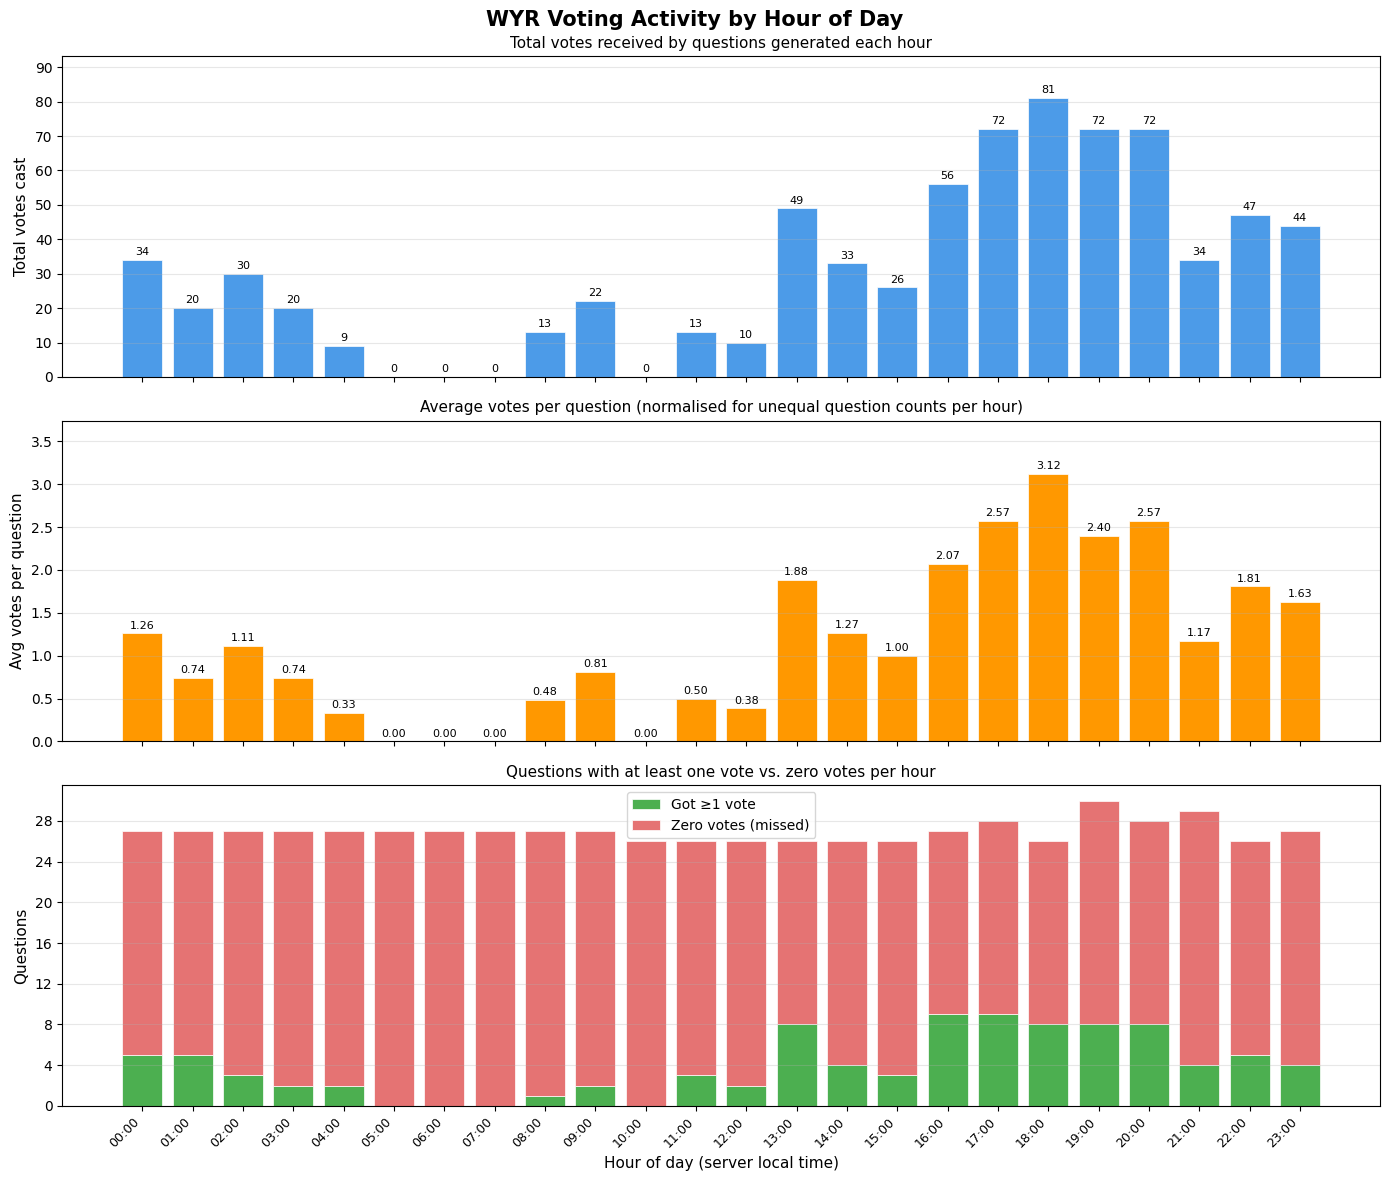

Saved → voting_by_hour.png


In [3]:
hours = by_hour.index
labels = [f"{h:02d}:00" for h in hours]

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
fig.suptitle("WYR Voting Activity by Hour of Day", fontsize=15, fontweight="bold", y=0.98)

BAR_COLOR   = "#4C9BE8"
VOTED_COLOR = "#4CAF50"
MISS_COLOR  = "#E57373"
AVG_COLOR   = "#FF9800"

# ── Panel 1: total votes ────────────────────────────────────────────────────
ax1 = axes[0]
bars = ax1.bar(hours, by_hour["total_votes"], color=BAR_COLOR, edgecolor="white", linewidth=0.5)
ax1.set_ylabel("Total votes cast", fontsize=11)
ax1.set_title("Total votes received by questions generated each hour", fontsize=11)
ax1.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
ax1.bar_label(bars, padding=2, fontsize=8)
ax1.set_ylim(0, by_hour["total_votes"].max() * 1.15)
ax1.grid(axis="y", alpha=0.3)

# ── Panel 2: average votes per question ─────────────────────────────────────
ax2 = axes[1]
bars2 = ax2.bar(hours, by_hour["avg_votes"], color=AVG_COLOR, edgecolor="white", linewidth=0.5)
ax2.set_ylabel("Avg votes per question", fontsize=11)
ax2.set_title("Average votes per question (normalised for unequal question counts per hour)", fontsize=11)
ax2.bar_label(bars2, fmt="%.2f", padding=2, fontsize=8)
ax2.set_ylim(0, by_hour["avg_votes"].max() * 1.2)
ax2.grid(axis="y", alpha=0.3)

# ── Panel 3: voted vs unvoted questions stacked ─────────────────────────────
ax3 = axes[2]
ax3.bar(hours, by_hour["voted_q"],   color=VOTED_COLOR, edgecolor="white", linewidth=0.5, label="Got ≥1 vote")
ax3.bar(hours, by_hour["unvoted_q"], color=MISS_COLOR,  edgecolor="white", linewidth=0.5,
        bottom=by_hour["voted_q"], label="Zero votes (missed)")
ax3.set_ylabel("Questions", fontsize=11)
ax3.set_title("Questions with at least one vote vs. zero votes per hour", fontsize=11)
ax3.legend(fontsize=10)
ax3.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
ax3.grid(axis="y", alpha=0.3)

# Shared x-axis formatting
ax3.set_xticks(hours)
ax3.set_xticklabels(labels, rotation=45, ha="right", fontsize=9)
ax3.set_xlabel("Hour of day (server local time)", fontsize=11)

fig.tight_layout()
plt.savefig("voting_by_hour.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → voting_by_hour.png")

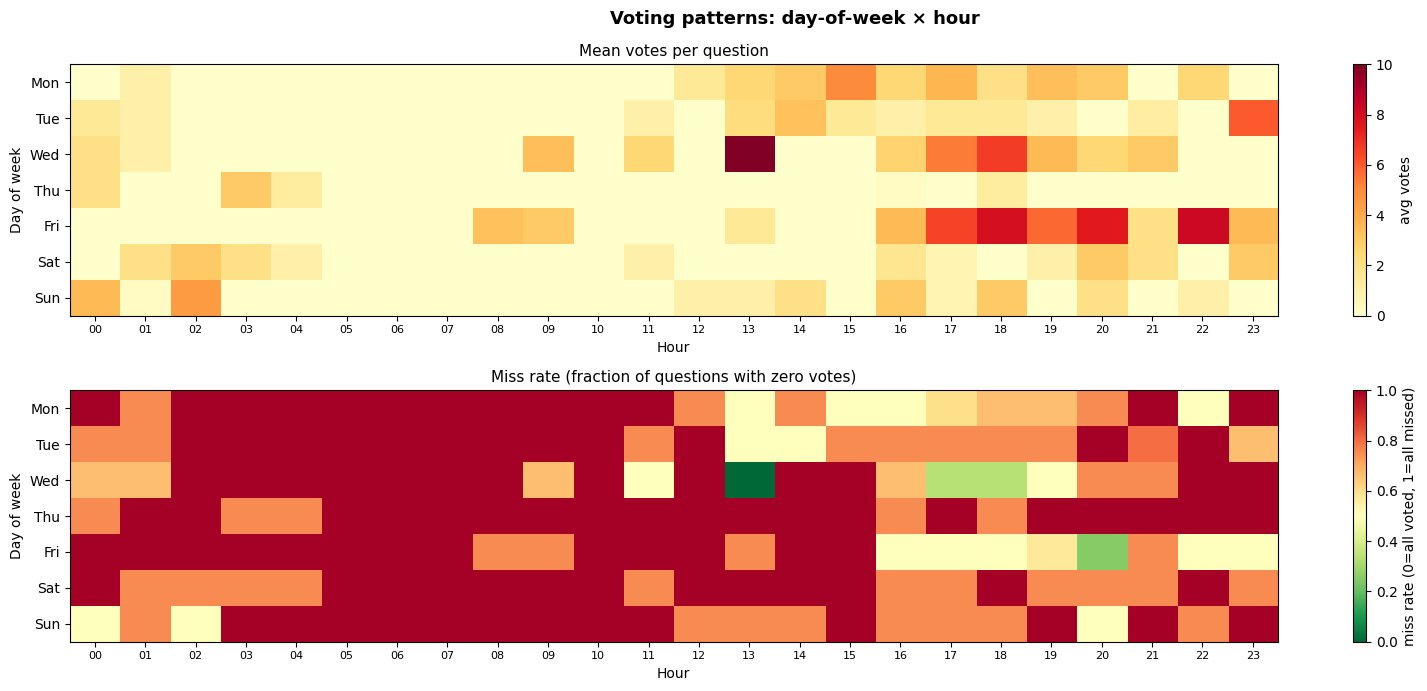

Saved → voting_heatmap_dow.png


In [4]:
# ── Miss-rate heatmap: day-of-week × hour ───────────────────────────────────
# Shows whether dead zones are consistent across all days or just weekdays/weekends.

df_raw["dow"] = pd.to_datetime(df_raw["date"]).dt.dayofweek  # 0=Mon … 6=Sun
DOW_LABELS = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

pivot_votes = df_raw.pivot_table(
    index="dow", columns="hour", values="total_votes", aggfunc="mean"
).reindex(index=range(7), columns=range(24), fill_value=0)

pivot_miss = df_raw.pivot_table(
    index="dow", columns="hour",
    values="total_votes",
    aggfunc=lambda s: (s == 0).mean()
).reindex(index=range(7), columns=range(24), fill_value=1.0)

fig, (ax_v, ax_m) = plt.subplots(2, 1, figsize=(16, 7))
fig.suptitle("Voting patterns: day-of-week × hour", fontsize=13, fontweight="bold")

im1 = ax_v.imshow(pivot_votes.values, aspect="auto", cmap="YlOrRd", interpolation="nearest")
ax_v.set_title("Mean votes per question", fontsize=11)
ax_v.set_yticks(range(7)); ax_v.set_yticklabels(DOW_LABELS)
ax_v.set_xticks(range(24)); ax_v.set_xticklabels([f"{h:02d}" for h in range(24)], fontsize=8)
ax_v.set_xlabel("Hour"); ax_v.set_ylabel("Day of week")
plt.colorbar(im1, ax=ax_v, label="avg votes")

im2 = ax_m.imshow(pivot_miss.values, aspect="auto", cmap="RdYlGn_r",
                  vmin=0, vmax=1, interpolation="nearest")
ax_m.set_title("Miss rate (fraction of questions with zero votes)", fontsize=11)
ax_m.set_yticks(range(7)); ax_m.set_yticklabels(DOW_LABELS)
ax_m.set_xticks(range(24)); ax_m.set_xticklabels([f"{h:02d}" for h in range(24)], fontsize=8)
ax_m.set_xlabel("Hour"); ax_m.set_ylabel("Day of week")
plt.colorbar(im2, ax=ax_m, label="miss rate (0=all voted, 1=all missed)")

fig.tight_layout()
plt.savefig("voting_heatmap_dow.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → voting_heatmap_dow.png")

In [5]:
# ── Summary stats ────────────────────────────────────────────────────────────
peak_vote_hour  = by_hour["total_votes"].idxmax()
peak_avg_hour   = by_hour["avg_votes"].idxmax()
deadest_hour    = by_hour["miss_rate"].idxmax()

print("=" * 50)
print(f"Peak hour (total votes):   {peak_vote_hour:02d}:00  ({by_hour.loc[peak_vote_hour, 'total_votes']} votes)")
print(f"Peak hour (avg per q):     {peak_avg_hour:02d}:00  ({by_hour.loc[peak_avg_hour, 'avg_votes']:.2f} avg)")
print(f"Deadest hour (miss rate):  {deadest_hour:02d}:00  ({by_hour.loc[deadest_hour, 'miss_rate']:.0%} missed)")
print()
print("Top 5 hours by avg votes per question:")
print(by_hour[["total_votes", "num_questions", "avg_votes", "miss_rate"]]
      .sort_values("avg_votes", ascending=False)
      .head(5)
      .to_string())
print()
print("Bottom 5 hours (deadest):")
print(by_hour[["total_votes", "num_questions", "avg_votes", "miss_rate"]]
      .sort_values("avg_votes")
      .head(5)
      .to_string())

Peak hour (total votes):   18:00  (81 votes)
Peak hour (avg per q):     18:00  (3.12 avg)
Deadest hour (miss rate):  05:00  (100% missed)

Top 5 hours by avg votes per question:
      total_votes  num_questions  avg_votes  miss_rate
hour                                                  
18             81             26   3.115385   0.692308
17             72             28   2.571429   0.678571
20             72             28   2.571429   0.714286
19             72             30   2.400000   0.733333
16             56             27   2.074074   0.666667

Bottom 5 hours (deadest):
      total_votes  num_questions  avg_votes  miss_rate
hour                                                  
6               0             27   0.000000   1.000000
7               0             27   0.000000   1.000000
5               0             27   0.000000   1.000000
10              0             26   0.000000   1.000000
4               9             27   0.333333   0.925926
